# ***Data Loading and Setup***

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd drive/MyDrive/symantic-1.1.0.6/symantic/
!ls

/content/drive/MyDrive/symantic-1.1.0.6/symantic
data					model.py
DimensionalFeatureSpaceConstruction.py	pareto_new.py
DimensionalRegressor.py			__pycache__
FeatureSpaceConstruction.py		Regressor.py
__init__.py				test.ipynb
interpretable_aqueous_solubility


In [3]:

!pip -q install TorchSisso rdkit gpytorch mordredcommunity[full]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.0/176.0 kB 12.8 MB/s eta 0:00:00


# ***TorchSISSO***

In [4]:
import numpy as np
from collections import Counter
import pandas as pd
from rdkit import Chem
from rdkit import RDLogger
from mordred import Calculator, descriptors
from rdkit.Chem import AllChem, Descriptors
from scipy.stats import spearmanr
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_regression, r_regression

RDLogger.DisableLog('rdApp.*')
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

from TorchSisso import SissoModel
print("\nRunning TorchSISSO...")

aq_train_df = pd.read_csv('./data/aq_sol.csv')
aq_train_df.drop(aq_train_df.columns[0],axis = 1, inplace = True)
aq_train_df = aq_train_df.loc[:, aq_train_df.min() != 0]

ochem_test = pd.read_csv('./data/ochem.csv')
ochem_test.drop(ochem_test.columns[0],axis = 1, inplace = True)
biogen_test = pd.read_csv('./data/biogen.csv')
biogen_test.drop(biogen_test.columns[0],axis = 1, inplace = True)

from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(
    aq_train_df,
    test_size=0.2,
    stratify=pd.cut(aq_train_df['logS'], bins=10, labels=False),
    random_state=42
)
df_train.reset_index(drop=True,inplace=True);df_test.reset_index(drop=True,inplace=True)

sm = SissoModel(
    df_train,
    operators=['+','*','-','/'],#,'pow(2)',],
    n_term=2,
    n_expansion=3,
    initial_screening = ['spearman',0.10],
    k=30,
)

fit_rmse, equation_str, fit_r2, eqn_terms = sm.fit()

for equation_str in eqn_terms:
  print('Evaluating Equation::', equation_str)
  print()
  p,_ = sm.evaluate(equation_str,df_test)
  from sklearn.metrics import root_mean_squared_error
  print('RMSE: ',root_mean_squared_error(df_test.logS, p),'R2: ',r2_score(df_test.logS, p))

  p,_ = sm.evaluate(equation_str,ochem_test)
  from sklearn.metrics import root_mean_squared_error
  print('RMSE: ',root_mean_squared_error(ochem_test.logS, p),'R2: ',r2_score(ochem_test.logS, p))

  p,_ = sm.evaluate(equation_str,biogen_test)
  from sklearn.metrics import root_mean_squared_error
  print('RMSE: ',root_mean_squared_error(biogen_test.logS, p),'R2: ',r2_score(biogen_test.logS, p))



Running TorchSISSO...
************************************************ Starting Feature Space Construction in cpu ************************************************ 



************************************************ Starting 1 level of feature expansion...************************************************ 

************************************************ 1 Feature Expansion Completed with feature space size::: 181 ************************************************ 

************************************************ Time taken to create the space is::: 0.19095683097839355  Seconds...************************************************ 

************************************************ Starting 2 level of feature expansion...************************************************ 

************************************************ 2 Feature Expansion Completed with feature space size::: 78383 ************************************************ 

************************************************ Time taken 

## ***Residual GP Section***

In [5]:
import torch
import gpytorch
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

best_eq = eqn_terms[1]

train_preds, _ = sm.evaluate(best_eq, df_train)
train_residuals = df_train['logS'].values - train_preds

feature_cols = [c for c in df_train.columns if c != 'logS']

X_train_raw  = df_train[feature_cols].values
X_test_raw   = df_test[feature_cols].values
X_ochem_raw  = ochem_test[feature_cols].values
X_biogen_raw = biogen_test[feature_cols].values

# train-only imputation
imputer = SimpleImputer(strategy='median')
X_train_raw  = imputer.fit_transform(X_train_raw)
X_test_raw   = imputer.transform(X_test_raw)
X_ochem_raw  = imputer.transform(X_ochem_raw)
X_biogen_raw = imputer.transform(X_biogen_raw)

# train-only scaling
scaler = StandardScaler()
X_train_np  = scaler.fit_transform(X_train_raw)
X_test_np   = scaler.transform(X_test_raw)
X_ochem_np  = scaler.transform(X_ochem_raw)
X_biogen_np = scaler.transform(X_biogen_raw)

# standardize residual target
res_mean = train_residuals.mean()
res_std = train_residuals.std()
if res_std < 1e-12:
    res_std = 1.0
y_train_res_np = (train_residuals - res_mean) / res_std

X_train  = torch.tensor(X_train_np, dtype=torch.float32)
X_test   = torch.tensor(X_test_np, dtype=torch.float32)
X_ochem  = torch.tensor(X_ochem_np, dtype=torch.float32)
X_biogen = torch.tensor(X_biogen_np, dtype=torch.float32)
y_train_res = torch.tensor(y_train_res_np, dtype=torch.float32)

class ResidualGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ZeroMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.MaternKernel(
                nu=2.5,
                ard_num_dims=train_x.shape[1]
            )
        )

    def forward(self, x):
        return gpytorch.distributions.MultivariateNormal(
            self.mean_module(x),
            self.covar_module(x)
        )

likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ResidualGP(X_train, y_train_res, likelihood)

model.train()
likelihood.train()

optimizer = torch.optim.Adam(model.parameters(), lr=0.03)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

N_ITER = 200
for i in range(N_ITER):
    optimizer.zero_grad()
    output = model(X_train)
    loss = -mll(output, y_train_res)
    loss.backward()
    optimizer.step()

    if (i + 1) % 10 == 0 or i == 0:
        noise = likelihood.noise.item()
        ls_all = model.covar_module.base_kernel.lengthscale.detach().squeeze()
        ls_mean = ls_all.mean().item()
        ls_min = ls_all.min().item()
        ls_max = ls_all.max().item()
        os = model.covar_module.outputscale.item()

        print(
            f"Iter {i+1:3d} | Loss: {loss.item():.4f} | "
            f"noise: {noise:.4f} | outputscale: {os:.4f} | "
            f"ls_mean: {ls_mean:.4f} | ls_min: {ls_min:.4f} | ls_max: {ls_max:.4f}"
        )

model.eval()
likelihood.eval()

ls_values = model.covar_module.base_kernel.lengthscale.detach().squeeze().numpy()
ls_df = pd.DataFrame({
    'feature': feature_cols,
    'lengthscale': ls_values
}).sort_values('lengthscale')

print("\nTop 10 most important features (smallest lengthscale):")
print(ls_df.head(10).to_string(index=False))

print("\nTop 10 least important features (largest lengthscale):")
print(ls_df.tail(10).to_string(index=False))

def predict_combined(X_tensor, df_ref, equation_str, model, likelihood, sm, res_mean, res_std):
    model.eval()
    likelihood.eval()

    sisso_pred, _ = sm.evaluate(equation_str, df_ref)

    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        gp_dist = likelihood(model(X_tensor))
        gp_mean = gp_dist.mean.numpy() * res_std + res_mean
        gp_std  = gp_dist.stddev.numpy() * res_std

    final_pred = sisso_pred + gp_mean
    return final_pred, gp_std, sisso_pred

splits = {
    'aq_test': (X_test, df_test, df_test['logS'].values),
    'ochem': (X_ochem, ochem_test, ochem_test['logS'].values),
    'biogen': (X_biogen, biogen_test, biogen_test['logS'].values),
}

for name, (X_t, df_t, y_true) in splits.items():
    final, std, base = predict_combined(
        X_t, df_t, best_eq, model, likelihood, sm, res_mean, res_std
    )

    print(f"\n── {name} ──")
    print(f"  SISSO alone -- RMSE: {root_mean_squared_error(y_true, base):.4f}  "
          f"R2: {r2_score(y_true, base):.4f}")
    print(f"  SISSO + GP  -- RMSE: {root_mean_squared_error(y_true, final):.4f}  "
          f"R2: {r2_score(y_true, final):.4f}")

Iter   1 | Loss: 1.2809 | noise: 0.6784 | outputscale: 0.7083 | ls_mean: 0.7058 | ls_min: 0.6783 | ls_max: 0.7083
Iter  10 | Loss: 1.2477 | noise: 0.5559 | outputscale: 0.8548 | ls_mean: 0.7841 | ls_min: 0.5549 | ls_max: 0.8531
Iter  20 | Loss: 1.2165 | noise: 0.4472 | outputscale: 1.0553 | ls_mean: 0.8225 | ls_min: 0.4300 | ls_max: 1.0261
Iter  30 | Loss: 1.1985 | noise: 0.3626 | outputscale: 1.2962 | ls_mean: 0.8338 | ls_min: 0.3383 | ls_max: 1.2032
Iter  40 | Loss: 1.1803 | noise: 0.2949 | outputscale: 1.5509 | ls_mean: 0.8389 | ls_min: 0.3003 | ls_max: 1.3671
Iter  50 | Loss: 1.1747 | noise: 0.2413 | outputscale: 1.8111 | ls_mean: 0.8338 | ls_min: 0.3040 | ls_max: 1.4992
Iter  60 | Loss: 1.1989 | noise: 0.2026 | outputscale: 2.0567 | ls_mean: 0.8064 | ls_min: 0.2813 | ls_max: 1.6159
Iter  70 | Loss: 1.2072 | noise: 0.1749 | outputscale: 2.2312 | ls_mean: 0.7775 | ls_min: 0.2875 | ls_max: 1.6947
Iter  80 | Loss: 1.2068 | noise: 0.1525 | outputscale: 2.3034 | ls_mean: 0.7718 | ls_min

## ***Joint parameter training***

In [7]:
#This is crude version we can improve the accuracy with the tune of parameters with composite Kernel and MLL prper training
import torch
import torch.nn as nn
import gpytorch
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import re

best_eq = eqn_terms[1]
print(f"Equation:\n  {best_eq}\n")


def parse_sisso_equation(equation_str: str):
    tokens, current, depth = [], "", 0
    s = equation_str.strip()
    for i, ch in enumerate(s):
        if ch in "([":   depth += 1; current += ch
        elif ch in ")]": depth -= 1; current += ch
        elif ch in "+-" and depth == 0 and i > 0:
            if current.strip(): tokens.append(current.strip())
            current = ch
        else: current += ch
    if current.strip(): tokens.append(current.strip())

    coefficients, expressions, constant = [], [], 0.0
    pat = re.compile(r'^([+-]?\s*\d+[\d.eE+\-]*)(?:\s*\*\s*(.+))?$')

    for tok in tokens:
        m = pat.match(tok.strip())
        if m:
            coef_str = m.group(1).replace(" ", "")
            expr     = m.group(2)
            if expr and expr.strip():
                coefficients.append(float(coef_str))
                expressions.append(expr.strip())
            else:
                constant += float(coef_str)
        else:
            print(f"  [warn] fallback parse for token: {tok!r}")
            coefficients.append(1.0)
            expressions.append(tok)

    return coefficients, expressions, constant

coefficients, expressions, constant = parse_sisso_equation(best_eq)
print(f"Found {len(expressions)} feature term(s) + constant = {constant:.6f}")
for c, e in zip(coefficients, expressions):
    print(f"  w0={c:.6g}  x  {e}")


def get_basis(sm, expressions, df):
    return np.stack([sm.evaluate(expr, df)[0] for expr in expressions], axis=1)

Phi_train  = get_basis(sm, expressions, df_train)
Phi_test   = get_basis(sm, expressions, df_test)
Phi_ochem  = get_basis(sm, expressions, ochem_test)
Phi_biogen = get_basis(sm, expressions, biogen_test)

feature_cols = [c for c in df_train.columns if c != 'logS']
n_desc = len(feature_cols)

imputer = SimpleImputer(strategy='median')
X_train_np  = imputer.fit_transform(df_train[feature_cols].values)
X_test_np   = imputer.transform(df_test[feature_cols].values)
X_ochem_np  = imputer.transform(ochem_test[feature_cols].values)
X_biogen_np = imputer.transform(biogen_test[feature_cols].values)

scaler = StandardScaler()
X_train_np  = scaler.fit_transform(X_train_np)
X_test_np   = scaler.transform(X_test_np)
X_ochem_np  = scaler.transform(X_ochem_np)
X_biogen_np = scaler.transform(X_biogen_np)

def make_aug(X_np, Phi_np):
    return torch.tensor(
        np.concatenate([X_np, Phi_np], axis=1), dtype=torch.float32
    )

X_train_aug  = make_aug(X_train_np,  Phi_train)
X_test_aug   = make_aug(X_test_np,   Phi_test)
X_ochem_aug  = make_aug(X_ochem_np,  Phi_ochem)
X_biogen_aug = make_aug(X_biogen_np, Phi_biogen)

y_train = torch.tensor(df_train['logS'].values, dtype=torch.float32)

n_terms = len(expressions)
print(f"\nAugmented input dim: {X_train_aug.shape[1]} "
      f"({n_desc} descriptors + {n_terms} SISSO terms)")

class SISSOParametricMean(gpytorch.means.Mean):

    def __init__(self, n_desc, n_terms, init_weights, init_bias):
        super().__init__()
        self.n_desc   = n_desc
        self.n_terms  = n_terms
        self.weights  = nn.Parameter(torch.tensor(init_weights, dtype=torch.float32))
        self.bias     = nn.Parameter(torch.tensor([init_bias],  dtype=torch.float32))

    def forward(self, x):
        Phi = x[:, self.n_desc:]
        return Phi @ self.weights + self.bias

class JointSISSOGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, n_desc, n_terms,
                 init_weights, init_bias):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module  = SISSOParametricMean(
            n_desc, n_terms, init_weights, init_bias
        )
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.MaternKernel(
                nu=2.5,
                ard_num_dims=n_desc
            )
        )

    def forward(self, x):
        x_desc = x[:, :self.mean_module.n_desc]
        return gpytorch.distributions.MultivariateNormal(
            self.mean_module(x),
            self.covar_module(x_desc)
        )

likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = JointSISSOGP(
    X_train_aug, y_train, likelihood,
    n_desc, n_terms,
    init_weights=coefficients,
    init_bias=constant
)

sisso_ref, _ = sm.evaluate(best_eq, df_train)
with torch.no_grad():
    init_mean = model.mean_module(X_train_aug).numpy()

model.train(); likelihood.train()

optimizer = torch.optim.Adam([
    {'params': list(model.mean_module.parameters()),  'lr': 1e-3},
    {'params': list(model.covar_module.parameters()), 'lr': 1e-2},
    {'params': list(likelihood.parameters()),         'lr': 1e-2},
])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=300, eta_min=1e-5
)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

N_ITER = 100
for i in range(N_ITER):
    optimizer.zero_grad()
    loss = -mll(model(X_train_aug), y_train)
    loss.backward()
    optimizer.step()
    scheduler.step()

    #if (i + 1) % 50 == 0 or i == 0:
    w     = model.mean_module.weights.detach().numpy()
    b     = model.mean_module.bias.detach().item()
    ls    = model.covar_module.base_kernel.lengthscale.detach().squeeze()
    noise = likelihood.noise.item()
    os    = model.covar_module.outputscale.item()
    print(f"Iter {i+1:3d} | Loss: {loss.item():.4f} | "
          f"noise: {noise:.4f} | os: {os:.4f} | "
          f"ls_mean: {ls.mean().item():.4f} | "
          f"w: {np.round(w, 4)} | b: {b:.4f}")

print("\n── Original vs Learned coefficients ──")
w_final = model.mean_module.weights.detach().numpy()
b_final = model.mean_module.bias.detach().item()
for expr, w_orig, w_new in zip(expressions, coefficients, w_final):
    print(f"  {w_orig:+.6g}  --  {w_new:+.6g}   x  {expr}")
print(f"  {constant:+.6g}  --  {b_final:+.6g}   (bias/constant)")

def predict_joint(X_aug, Phi_np, y_true, model, likelihood,
                  coefficients, constant, label):
    model.eval(); likelihood.eval()

    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        gp_dist    = likelihood(model(X_aug))
        final_pred = gp_dist.mean.numpy()
        gp_std     = gp_dist.stddev.numpy()

    sisso_base = Phi_np @ np.array(coefficients) + constant

    print(f"\n── {label} ──")
    print(f"  SISSO alone -- RMSE: {root_mean_squared_error(y_true, sisso_base):.4f}  "
          f"R2: {r2_score(y_true, sisso_base):.4f}")
    print(f"  Joint GP    -- RMSE: {root_mean_squared_error(y_true, final_pred):.4f}  "
          f"R2: {r2_score(y_true, final_pred):.4f}")

splits = {
    'aq_test': (X_test_aug,   Phi_test,   df_test['logS'].values),
    'ochem'  : (X_ochem_aug,  Phi_ochem,  ochem_test['logS'].values),
    'biogen' : (X_biogen_aug, Phi_biogen, biogen_test['logS'].values),
}
for label, (X_aug, Phi_np, y_true) in splits.items():
    predict_joint(X_aug, Phi_np, y_true, model, likelihood,
                  coefficients, constant, label)


Equation:
   + 0.0369610856*((MolLogP*LabuteASA)/(MolLogP-Chi0v))   + 814.0823605833*((Chi0v/LabuteASA)/(LabuteASA-HeavyAtomCount))  -2.8660430073820478

Found 2 feature term(s) + constant = -2.866043
  w0=0.0369611  x  ((MolLogP*LabuteASA)/(MolLogP-Chi0v))
  w0=814.082  x  ((Chi0v/LabuteASA)/(LabuteASA-HeavyAtomCount))

Augmented input dim: 14 (12 descriptors + 2 SISSO terms)
Iter   1 | Loss: 1.5721 | noise: 0.6983 | os: 0.6982 | ls_mean: 0.6932 | w: [3.600000e-02 8.140814e+02] | b: -2.8650
Iter   2 | Loss: 1.5682 | noise: 0.7033 | os: 0.7032 | ls_mean: 0.6931 | w: [3.500000e-02 8.140804e+02] | b: -2.8641
Iter   3 | Loss: 1.5662 | noise: 0.7083 | os: 0.7082 | ls_mean: 0.6931 | w: [3.400000e-02 8.140794e+02] | b: -2.8633
Iter   4 | Loss: 1.5637 | noise: 0.7134 | os: 0.7133 | ls_mean: 0.6931 | w: [3.310000e-02 8.140784e+02] | b: -2.8628
Iter   5 | Loss: 1.5617 | noise: 0.7184 | os: 0.7184 | ls_mean: 0.6931 | w: [3.220000e-02 8.140774e+02] | b: -2.8626
Iter   6 | Loss: 1.5581 | noise: 0.

# ***SyMANTIC***

****************************** Initial Feature Expansion Completed with feature space size:  189 *********************************************** 

**************************************** Time taken to create the space is::: 0.011309623718261719  Seconds ********************************************

************************************ 2 Feature Expansion Completed with feature space size::: 89019  *********************************************************** 

****************************************** Time taken to create the space is::: 21.44700527191162  Seconds *************************************************** 

Expanded feature space is:: 89019
!!Warning:: Further feature expansions result in memory consumption, Please provide the input to consider feature expansion or to exit the run with the sparse models created!!!
Exiting based on user input.
************************************************ Autodepth regression completed in:: 39.794050216674805 seconds ***********************

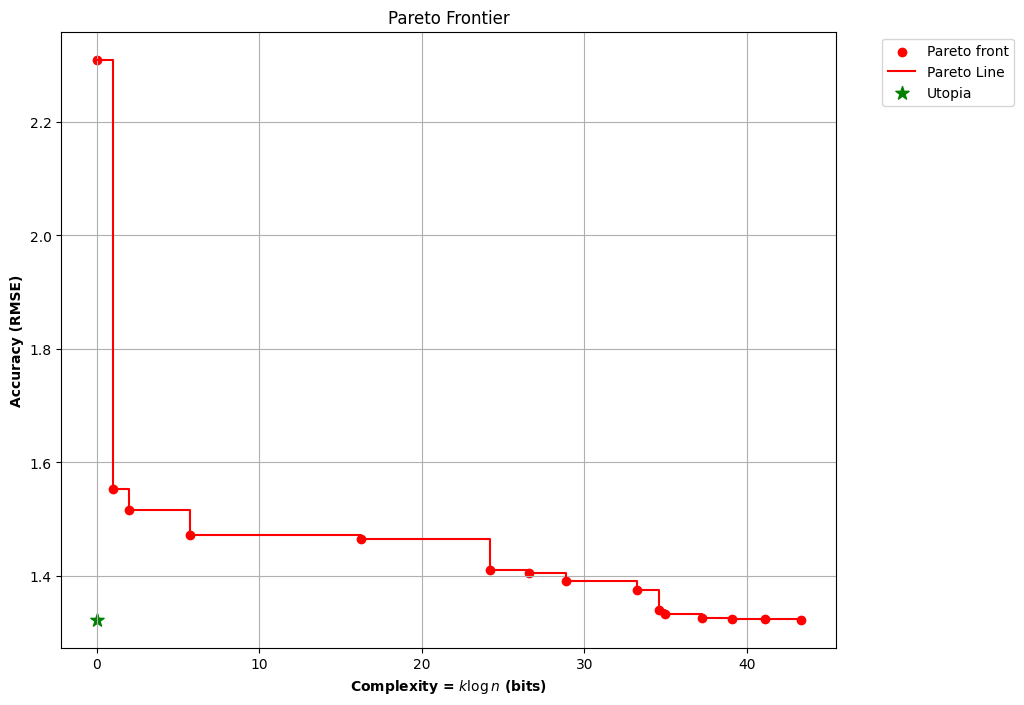

..............#############################################..........................

Evaluating Equation::  -0.6738200152809286*MolLogP - 1.4982008415090926
Test RMSE: 1.5090, R2: 0.5690
Ochem Test RMSE: 1.7519, R2: 0.3234
Biogen Test RMSE: 1.1326, R2: -1.5437
..............#############################################..........................

..............#############################################..........................

Evaluating Equation::  -0.6151806205588495*MolLogP + -0.0026736501500435844*HeavyAtomMolWt - 0.9798770072359311
Test RMSE: 1.4561, R2: 0.5987
Ochem Test RMSE: 1.6186, R2: 0.4224
Biogen Test RMSE: 1.0690, R2: -1.2662
..............#############################################..........................

..............#############################################..........................

Evaluating Equation::  -0.6297674998050353*MolLogP + 1.289557048482835*(NumValenceElectrons/HeavyAtomCount) - 8.665465888636989
Test RMSE: 1.4297, R2: 0.6131
Ochem Test RMSE

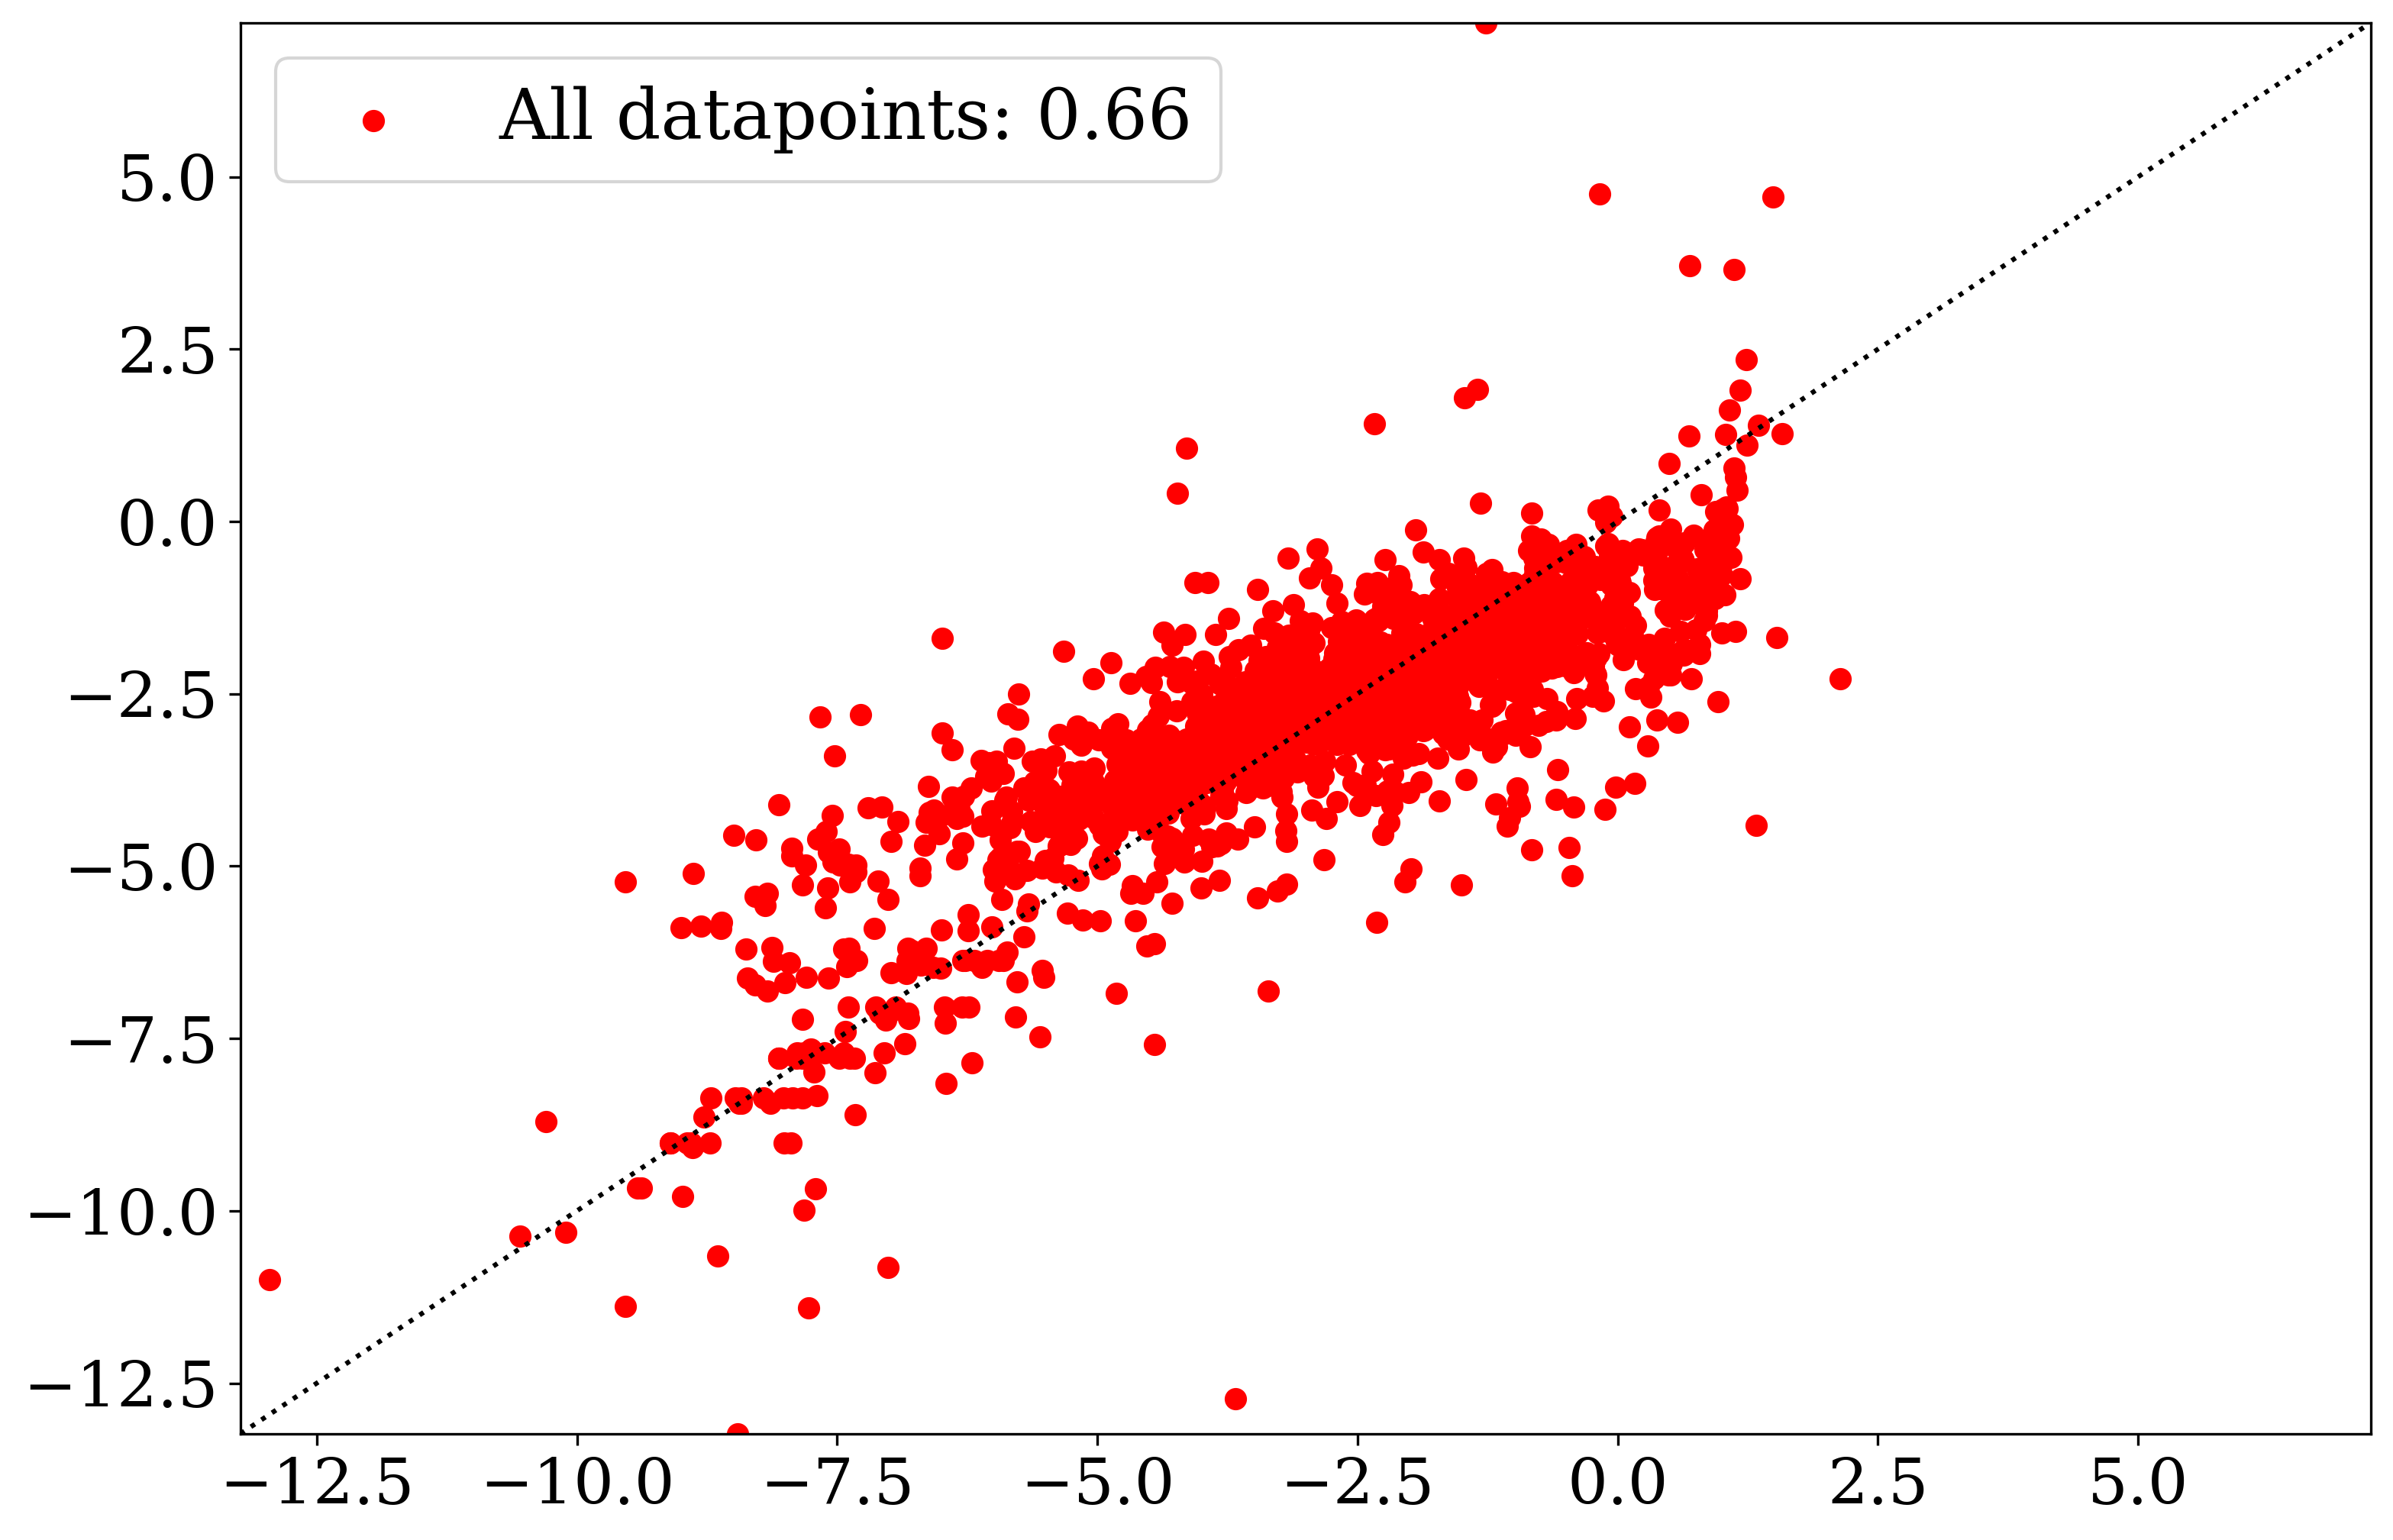

In [8]:
from model import SymanticModel
from sklearn.metrics import mean_squared_error, r2_score,root_mean_squared_error

operators = ['+','-','*','/']#,'exp','ln','pow(2)','pow(3)','pow(1/2)']

symantic = SymanticModel(df_train,operators=operators,disp=True,metrics=[0.05,0.99],initial_screening=['spearman',0.10],
                         n_term = 2, sis_features=30)
from unittest.mock import patch
with patch('builtins.input', return_value='no'):
    res, pareto = symantic.fit()

symantic.plot_pareto_front()

for eq in pareto.Equation[1:].tolist():
    try:
        print('..............#############################################..........................')
        print()
        print('Evaluating Equation:: ',eq)
        p,_ = symantic.evaluate(eq,df_test)
        p1,_ = symantic.evaluate(eq,ochem_test)
        p2,_ = symantic.evaluate(eq,biogen_test)
        rmse = root_mean_squared_error(df_test.logS,p)
        r2 = r2_score(df_test['logS'],p)
        print(f"Test RMSE: {rmse:.4f}, R2: {r2:.4f}")
        rmse = root_mean_squared_error(ochem_test.logS,p1)
        r2 = r2_score(ochem_test['logS'],p1)
        print(f"Ochem Test RMSE: {rmse:.4f}, R2: {r2:.4f}")
        rmse = root_mean_squared_error(biogen_test.logS,p2)
        r2 = r2_score(biogen_test['logS'],p2)
        print(f"Biogen Test RMSE: {rmse:.4f}, R2: {r2:.4f}")
        print('..............#############################################..........................')
        print()
    except Exception as e:
        print("Error evaluating equation:", e)

import matplotlib
matplotlib.rcParams.update({ "font.size": 22, "axes.labelsize": 24, "xtick.labelsize": 20, "ytick.labelsize": 20, "figure.dpi": 300, "font.family": "serif", })
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
p,_ = symantic.evaluate(pareto.Equation.tolist()[-1],df_test)
plt.scatter(df_test.logS,p,label=f"All datapoints: {r2_score(df_test.logS,p):.2f}",color='red')
plt.legend()
plt.plot([p.min(),p.max()],[p.min(),p.max()],'k:')
plt.xlim([p.min(),p.max()])
plt.ylim([p.min(),p.max()])
plt.show()



## **SyMANTIC - GP Section**

In [9]:
import torch
import gpytorch
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

best_eq = pareto.Equation[1:].tolist()[-2]

train_preds, _ = sm.evaluate(best_eq, df_train)
train_residuals = df_train['logS'].values - train_preds

feature_cols = [c for c in df_train.columns if c != 'logS']

X_train_raw  = df_train[feature_cols].values
X_test_raw   = df_test[feature_cols].values
X_ochem_raw  = ochem_test[feature_cols].values
X_biogen_raw = biogen_test[feature_cols].values

# train-only imputation
imputer = SimpleImputer(strategy='median')
X_train_raw  = imputer.fit_transform(X_train_raw)
X_test_raw   = imputer.transform(X_test_raw)
X_ochem_raw  = imputer.transform(X_ochem_raw)
X_biogen_raw = imputer.transform(X_biogen_raw)

# train-only scaling
scaler = StandardScaler()
X_train_np  = scaler.fit_transform(X_train_raw)
X_test_np   = scaler.transform(X_test_raw)
X_ochem_np  = scaler.transform(X_ochem_raw)
X_biogen_np = scaler.transform(X_biogen_raw)

# standardize residual target
res_mean = train_residuals.mean()
res_std = train_residuals.std()
if res_std < 1e-12:
    res_std = 1.0
y_train_res_np = (train_residuals - res_mean) / res_std

X_train  = torch.tensor(X_train_np, dtype=torch.float32)
X_test   = torch.tensor(X_test_np, dtype=torch.float32)
X_ochem  = torch.tensor(X_ochem_np, dtype=torch.float32)
X_biogen = torch.tensor(X_biogen_np, dtype=torch.float32)
y_train_res = torch.tensor(y_train_res_np, dtype=torch.float32)

class ResidualGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ZeroMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.MaternKernel(
                nu=2.5,
                ard_num_dims=train_x.shape[1]
            )
        )

    def forward(self, x):
        return gpytorch.distributions.MultivariateNormal(
            self.mean_module(x),
            self.covar_module(x)
        )

likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ResidualGP(X_train, y_train_res, likelihood)

model.train()
likelihood.train()

optimizer = torch.optim.Adam(model.parameters(), lr=0.03)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

N_ITER = 200
for i in range(N_ITER):
    optimizer.zero_grad()
    output = model(X_train)
    loss = -mll(output, y_train_res)
    loss.backward()
    optimizer.step()

    if (i + 1) % 10 == 0 or i == 0:
        noise = likelihood.noise.item()
        ls_all = model.covar_module.base_kernel.lengthscale.detach().squeeze()
        ls_mean = ls_all.mean().item()
        ls_min = ls_all.min().item()
        ls_max = ls_all.max().item()
        os = model.covar_module.outputscale.item()

        print(
            f"Iter {i+1:3d} | Loss: {loss.item():.4f} | "
            f"noise: {noise:.4f} | outputscale: {os:.4f} | "
            f"ls_mean: {ls_mean:.4f} | ls_min: {ls_min:.4f} | ls_max: {ls_max:.4f}"
        )

model.eval()
likelihood.eval()

ls_values = model.covar_module.base_kernel.lengthscale.detach().squeeze().numpy()
ls_df = pd.DataFrame({
    'feature': feature_cols,
    'lengthscale': ls_values
}).sort_values('lengthscale')

print("\nTop 10 most important features (smallest lengthscale):")
print(ls_df.head(10).to_string(index=False))

print("\nTop 10 least important features (largest lengthscale):")
print(ls_df.tail(10).to_string(index=False))

def predict_combined(X_tensor, df_ref, equation_str, model, likelihood, sm, res_mean, res_std):
    model.eval()
    likelihood.eval()

    sisso_pred, _ = sm.evaluate(equation_str, df_ref)

    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        gp_dist = likelihood(model(X_tensor))
        gp_mean = gp_dist.mean.numpy() * res_std + res_mean
        gp_std  = gp_dist.stddev.numpy() * res_std

    final_pred = sisso_pred + gp_mean
    return final_pred, gp_std, sisso_pred

splits = {
    'aq_test': (X_test, df_test, df_test['logS'].values),
    'ochem': (X_ochem, ochem_test, ochem_test['logS'].values),
    'biogen': (X_biogen, biogen_test, biogen_test['logS'].values),
}

for name, (X_t, df_t, y_true) in splits.items():
    final, std, base = predict_combined(
        X_t, df_t, best_eq, model, likelihood, sm, res_mean, res_std
    )

    print(f"\n── {name} ──")
    print(f"  SISSO alone -- RMSE: {root_mean_squared_error(y_true, base):.4f}  "
          f"R²: {r2_score(y_true, base):.4f}")
    print(f"  SISSO + GP -- RMSE: {root_mean_squared_error(y_true, final):.4f}  "
          f"R²: {r2_score(y_true, final):.4f}")

Iter   1 | Loss: 1.2805 | noise: 0.6784 | outputscale: 0.7083 | ls_mean: 0.7033 | ls_min: 0.6783 | ls_max: 0.7083
Iter  10 | Loss: 1.2466 | noise: 0.5559 | outputscale: 0.8545 | ls_mean: 0.7906 | ls_min: 0.5583 | ls_max: 0.8531
Iter  20 | Loss: 1.2176 | noise: 0.4471 | outputscale: 1.0553 | ls_mean: 0.8272 | ls_min: 0.4348 | ls_max: 1.0274
Iter  30 | Loss: 1.1991 | noise: 0.3628 | outputscale: 1.2956 | ls_mean: 0.8311 | ls_min: 0.3376 | ls_max: 1.2085
Iter  40 | Loss: 1.1821 | noise: 0.2962 | outputscale: 1.5482 | ls_mean: 0.8332 | ls_min: 0.3116 | ls_max: 1.3746
Iter  50 | Loss: 1.1867 | noise: 0.2439 | outputscale: 1.7995 | ls_mean: 0.8315 | ls_min: 0.3114 | ls_max: 1.5044
Iter  60 | Loss: 1.1866 | noise: 0.2050 | outputscale: 2.0460 | ls_mean: 0.8120 | ls_min: 0.2939 | ls_max: 1.6243
Iter  70 | Loss: 1.1975 | noise: 0.1758 | outputscale: 2.2344 | ls_mean: 0.7869 | ls_min: 0.2936 | ls_max: 1.7119
Iter  80 | Loss: 1.2117 | noise: 0.1526 | outputscale: 2.3424 | ls_mean: 0.7744 | ls_min

## **Joint Parameter training**

In [11]:
#This is crude version we can improve the accuracy with the tune of parameters with composite Kernel and MLL prper training
import torch
import torch.nn as nn
import gpytorch
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import re

best_eq = pareto.Equation[1:].tolist()[-2]
print(f"Equation:\n  {best_eq}\n")


def parse_sisso_equation(equation_str: str):
    tokens, current, depth = [], "", 0
    s = equation_str.strip()
    for i, ch in enumerate(s):
        if ch in "([":   depth += 1; current += ch
        elif ch in ")]": depth -= 1; current += ch
        elif ch in "+-" and depth == 0 and i > 0:
            if current.strip(): tokens.append(current.strip())
            current = ch
        else: current += ch
    if current.strip(): tokens.append(current.strip())

    coefficients, expressions, constant = [], [], 0.0
    pat = re.compile(r'^([+-]?\s*\d+[\d.eE+\-]*)(?:\s*\*\s*(.+))?$')

    for tok in tokens:
        m = pat.match(tok.strip())
        if m:
            coef_str = m.group(1).replace(" ", "")
            expr     = m.group(2)
            if expr and expr.strip():
                coefficients.append(float(coef_str))
                expressions.append(expr.strip())
            else:
                constant += float(coef_str)
        else:
            print(f"  [warn] fallback parse for token: {tok!r}")
            coefficients.append(1.0)
            expressions.append(tok)

    return coefficients, expressions, constant

coefficients, expressions, constant = parse_sisso_equation(best_eq)
print(f"Found {len(expressions)} feature term(s) + constant = {constant:.6f}")
for c, e in zip(coefficients, expressions):
    print(f"  w0={c:.6g}  x  {e}")


def get_basis(sm, expressions, df):
    return np.stack([sm.evaluate(expr, df)[0] for expr in expressions], axis=1)

Phi_train  = get_basis(sm, expressions, df_train)
Phi_test   = get_basis(sm, expressions, df_test)
Phi_ochem  = get_basis(sm, expressions, ochem_test)
Phi_biogen = get_basis(sm, expressions, biogen_test)

feature_cols = [c for c in df_train.columns if c != 'logS']
n_desc = len(feature_cols)

imputer = SimpleImputer(strategy='median')
X_train_np  = imputer.fit_transform(df_train[feature_cols].values)
X_test_np   = imputer.transform(df_test[feature_cols].values)
X_ochem_np  = imputer.transform(ochem_test[feature_cols].values)
X_biogen_np = imputer.transform(biogen_test[feature_cols].values)

scaler = StandardScaler()
X_train_np  = scaler.fit_transform(X_train_np)
X_test_np   = scaler.transform(X_test_np)
X_ochem_np  = scaler.transform(X_ochem_np)
X_biogen_np = scaler.transform(X_biogen_np)

def make_aug(X_np, Phi_np):
    return torch.tensor(
        np.concatenate([X_np, Phi_np], axis=1), dtype=torch.float32
    )

X_train_aug  = make_aug(X_train_np,  Phi_train)
X_test_aug   = make_aug(X_test_np,   Phi_test)
X_ochem_aug  = make_aug(X_ochem_np,  Phi_ochem)
X_biogen_aug = make_aug(X_biogen_np, Phi_biogen)

y_train = torch.tensor(df_train['logS'].values, dtype=torch.float32)

n_terms = len(expressions)
print(f"\nAugmented input dim: {X_train_aug.shape[1]} "
      f"({n_desc} descriptors + {n_terms} SISSO terms)")

class SISSOParametricMean(gpytorch.means.Mean):

    def __init__(self, n_desc, n_terms, init_weights, init_bias):
        super().__init__()
        self.n_desc   = n_desc
        self.n_terms  = n_terms
        self.weights  = nn.Parameter(torch.tensor(init_weights, dtype=torch.float32))
        self.bias     = nn.Parameter(torch.tensor([init_bias],  dtype=torch.float32))

    def forward(self, x):
        Phi = x[:, self.n_desc:]
        return Phi @ self.weights + self.bias

class JointSISSOGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, n_desc, n_terms,
                 init_weights, init_bias):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module  = SISSOParametricMean(
            n_desc, n_terms, init_weights, init_bias
        )
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.MaternKernel(
                nu=2.5,
                ard_num_dims=n_desc
            )
        )

    def forward(self, x):
        x_desc = x[:, :self.mean_module.n_desc]
        return gpytorch.distributions.MultivariateNormal(
            self.mean_module(x),
            self.covar_module(x_desc)
        )

likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = JointSISSOGP(
    X_train_aug, y_train, likelihood,
    n_desc, n_terms,
    init_weights=coefficients,
    init_bias=constant
)

sisso_ref, _ = sm.evaluate(best_eq, df_train)
with torch.no_grad():
    init_mean = model.mean_module(X_train_aug).numpy()

model.train(); likelihood.train()

optimizer = torch.optim.Adam([
    {'params': list(model.mean_module.parameters()),  'lr': 1e-3},
    {'params': list(model.covar_module.parameters()), 'lr': 1e-2},
    {'params': list(likelihood.parameters()),         'lr': 1e-2},
])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=300, eta_min=1e-5
)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

N_ITER = 100
for i in range(N_ITER):
    optimizer.zero_grad()
    loss = -mll(model(X_train_aug), y_train)
    loss.backward()
    optimizer.step()
    scheduler.step()

    #if (i + 1) % 50 == 0 or i == 0:
    w     = model.mean_module.weights.detach().numpy()
    b     = model.mean_module.bias.detach().item()
    ls    = model.covar_module.base_kernel.lengthscale.detach().squeeze()
    noise = likelihood.noise.item()
    os    = model.covar_module.outputscale.item()
    print(f"Iter {i+1:3d} | Loss: {loss.item():.4f} | "
          f"noise: {noise:.4f} | os: {os:.4f} | "
          f"ls_mean: {ls.mean().item():.4f} | "
          f"w: {np.round(w, 4)} | b: {b:.4f}")

print("\n── Original vs Learned coefficients ──")
w_final = model.mean_module.weights.detach().numpy()
b_final = model.mean_module.bias.detach().item()
for expr, w_orig, w_new in zip(expressions, coefficients, w_final):
    print(f"  {w_orig:+.6g}  --  {w_new:+.6g}   x  {expr}")
print(f"  {constant:+.6g}  --  {b_final:+.6g}   (bias/constant)")

def predict_joint(X_aug, Phi_np, y_true, model, likelihood,
                  coefficients, constant, label):
    model.eval(); likelihood.eval()

    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        gp_dist    = likelihood(model(X_aug))
        final_pred = gp_dist.mean.numpy()
        gp_std     = gp_dist.stddev.numpy()

    sisso_base = Phi_np @ np.array(coefficients) + constant

    print(f"\n── {label} ──")
    print(f"  SISSO alone -- RMSE: {root_mean_squared_error(y_true, sisso_base):.4f}  "
          f"R2: {r2_score(y_true, sisso_base):.4f}")
    print(f"  Joint GP    -- RMSE: {root_mean_squared_error(y_true, final_pred):.4f}  "
          f"R2: {r2_score(y_true, final_pred):.4f}")

splits = {
    'aq_test': (X_test_aug,   Phi_test,   df_test['logS'].values),
    'ochem'  : (X_ochem_aug,  Phi_ochem,  ochem_test['logS'].values),
    'biogen' : (X_biogen_aug, Phi_biogen, biogen_test['logS'].values),
}
for label, (X_aug, Phi_np, y_true) in splits.items():
    predict_joint(X_aug, Phi_np, y_true, model, likelihood,
                  coefficients, constant, label)


Equation:
  0.037155292304197465*((MolLogP*LabuteASA)/(MolLogP-Chi0v)) + 1052.1256690071527*((Chi0v/LabuteASA)/(LabuteASA+Chi0v)) - 2.8396457338678815

Found 2 feature term(s) + constant = -2.839646
  w0=0.0371553  x  ((MolLogP*LabuteASA)/(MolLogP-Chi0v))
  w0=1052.13  x  ((Chi0v/LabuteASA)/(LabuteASA+Chi0v))

Augmented input dim: 14 (12 descriptors + 2 SISSO terms)
Iter   1 | Loss: 1.5735 | noise: 0.6983 | os: 0.6982 | ls_mean: 0.6932 | w: [3.6200002e-02 1.0521246e+03] | b: -2.8386
Iter   2 | Loss: 1.5681 | noise: 0.7033 | os: 0.7032 | ls_mean: 0.6932 | w: [3.5200000e-02 1.0521237e+03] | b: -2.8377
Iter   3 | Loss: 1.5651 | noise: 0.7083 | os: 0.7082 | ls_mean: 0.6931 | w: [3.4200002e-02 1.0521227e+03] | b: -2.8369
Iter   4 | Loss: 1.5607 | noise: 0.7134 | os: 0.7133 | ls_mean: 0.6930 | w: [3.3199999e-02 1.0521217e+03] | b: -2.8363
Iter   5 | Loss: 1.5613 | noise: 0.7184 | os: 0.7184 | ls_mean: 0.6929 | w: [3.2299999e-02 1.0521207e+03] | b: -2.8362
Iter   6 | Loss: 1.5584 | noise: 0.7

# ***REGULAR GP***

In [18]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import gpytorch

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error


TARGET = "logS"
SEED = 42

USE_CUDA_IF_AVAILABLE = True

GP_NU = 2.5
GP_LR = 0.01
GP_TRAIN_ITERS = 250
MAX_GP_TRAIN = df_train.shape[0]

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def print_metrics(name, y_true, y_pred):
    print(f"{name:20s} | RMSE = {rmse(y_true, y_pred):.4f} | R2 = {r2_score(y_true, y_pred):.4f}")





# =============================================================================
# BUILD MATRICES
# =============================================================================
X_train_df = df_train.drop(columns=[TARGET])
y_train = df_train[TARGET].values.astype(np.float64)

X_test_df = df_test.drop(columns=[TARGET])
y_test = df_test[TARGET].values.astype(np.float64)

ochem_test = ochem_test.loc[:,df_train.columns.tolist()]
X_ochem_df = ochem_test.drop(columns=[TARGET])
y_ochem = ochem_test[TARGET].values.astype(np.float64)

biogen_test = biogen_test.loc[:,df_train.columns.tolist()]
X_biogen_df = biogen_test.drop(columns=[TARGET])
y_biogen = biogen_test[TARGET].values.astype(np.float64)

x_imputer = SimpleImputer(strategy="median")

X_train = x_imputer.fit_transform(X_train_df)
X_test = x_imputer.transform(X_test_df)
X_ochem = x_imputer.transform(X_ochem_df)
X_biogen = x_imputer.transform(X_biogen_df)

x_scaler = StandardScaler()
X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)
X_ochem = x_scaler.transform(X_ochem)
X_biogen = x_scaler.transform(X_biogen)

y_mean = y_train.mean()
y_std = y_train.std()
if y_std < 1e-12:
    y_std = 1.0

y_train_std = (y_train - y_mean) / y_std


# =============================================================================
# OPTIONAL SUBSAMPLING FOR EXACT GP
# =============================================================================
if len(X_train) > MAX_GP_TRAIN:
    rng = np.random.default_rng(SEED)
    idx = rng.choice(len(X_train), size=MAX_GP_TRAIN, replace=False)
    X_train_gp = X_train[idx]
    y_train_gp = y_train_std[idx]
    print(f"Using GP subset: {len(X_train_gp)} / {len(X_train)}")
else:
    X_train_gp = X_train
    y_train_gp = y_train_std


# =============================================================================
# TORCH TENSORS
# =============================================================================
device = "cuda" if (USE_CUDA_IF_AVAILABLE and torch.cuda.is_available()) else "cpu"
print("Using device:", device)

train_x = torch.tensor(X_train_gp, dtype=torch.float32, device=device)
train_y = torch.tensor(y_train_gp, dtype=torch.float32, device=device)

test_x = torch.tensor(X_test, dtype=torch.float32, device=device)
ochem_x = torch.tensor(X_ochem, dtype=torch.float32, device=device)
biogen_x = torch.tensor(X_biogen, dtype=torch.float32, device=device)


# =============================================================================
# EXACT GP MODEL: MATERN + ARD
# =============================================================================
class ExactMaternARDGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, nu=2.5):
        super().__init__(train_x, train_y, likelihood)
        input_dim = train_x.shape[1]

        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.MaternKernel(
                nu=nu,
                ard_num_dims=input_dim
            )
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
model = ExactMaternARDGP(train_x, train_y, likelihood, nu=GP_NU).to(device)


# =============================================================================
# TRAIN
# =============================================================================
model.train()
likelihood.train()

optimizer = torch.optim.AdamW(model.parameters(), lr=GP_LR)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

for i in range(1, GP_TRAIN_ITERS + 1):
    optimizer.zero_grad()
    output = model(train_x)
    loss = -mll(output, train_y)
    loss.backward()
    optimizer.step()

    if i == 1 or i % 25 == 0 or i == GP_TRAIN_ITERS:
        lengthscale = model.covar_module.base_kernel.lengthscale.detach().cpu().numpy().ravel()
        print(
            f"Iter {i:03d}/{GP_TRAIN_ITERS} | "
            f"Loss = {loss.item():.6f} | "
            f"Mean ARD lengthscale = {lengthscale.mean():.4f}"
        )


# =============================================================================
# PREDICT
# =============================================================================
model.eval()
likelihood.eval()

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    pred_test = likelihood(model(test_x))
    pred_ochem = likelihood(model(ochem_x))
    pred_biogen = likelihood(model(biogen_x))

# Convert predictions back to original y scale
yhat_test = pred_test.mean.detach().cpu().numpy() * y_std + y_mean
yhat_ochem = pred_ochem.mean.detach().cpu().numpy() * y_std + y_mean
yhat_biogen = pred_biogen.mean.detach().cpu().numpy() * y_std + y_mean

# Optional predictive std in original scale
ystd_test = pred_test.stddev.detach().cpu().numpy() * y_std
ystd_ochem = pred_ochem.stddev.detach().cpu().numpy() * y_std
ystd_biogen = pred_biogen.stddev.detach().cpu().numpy() * y_std


# =============================================================================
# METRICS
# =============================================================================
print("\n================ GPyTorch Exact GP (Matern + ARD) ================\n")
print_metrics("AqSol internal test", y_test, yhat_test)
print_metrics("OChem external", y_ochem, yhat_ochem)
print_metrics("Biogen external", y_biogen, yhat_biogen)


Using device: cpu
Iter 001/250 | Loss = 1.067512 | Mean ARD lengthscale = 0.6982
Iter 025/250 | Loss = 0.976156 | Mean ARD lengthscale = 0.8232
Iter 050/250 | Loss = 0.901110 | Mean ARD lengthscale = 0.9547
Iter 075/250 | Loss = 0.830484 | Mean ARD lengthscale = 1.0790
Iter 100/250 | Loss = 0.779560 | Mean ARD lengthscale = 1.1891
Iter 125/250 | Loss = 0.736818 | Mean ARD lengthscale = 1.2771
Iter 150/250 | Loss = 0.702687 | Mean ARD lengthscale = 1.3361
Iter 175/250 | Loss = 0.678965 | Mean ARD lengthscale = 1.3563
Iter 200/250 | Loss = 0.654562 | Mean ARD lengthscale = 1.3406
Iter 225/250 | Loss = 0.637350 | Mean ARD lengthscale = 1.3040
Iter 250/250 | Loss = 0.619437 | Mean ARD lengthscale = 1.2817

================ GPyTorch Exact GP (Matern + ARD) ================

AqSol internal test  | RMSE = 1.1325 | R2 = 0.7568
OChem external       | RMSE = 1.3826 | R2 = 0.5786
Biogen external      | RMSE = 1.0870 | R2 = -1.3432
